In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential 
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

tf.random.set_seed(1234)

In [3]:
X = np.load('./dataset/handsignX.npy')
y = np.load('./dataset/handsigny.npy')

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")




X_train, X_cv, y_train, y_cv = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_cv: {X_cv.shape}")
print(f"Shape of y_test: {y_cv.shape}")

print(X_cv)

m,n = X.shape


# np.imshow(X)

Shape of X: (5000, 400)
Shape of y: (5000, 1)
Shape of X_train: (4000, 400)
Shape of y_train: (4000, 1)
Shape of X_cv: (1000, 400)
Shape of y_test: (1000, 1)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


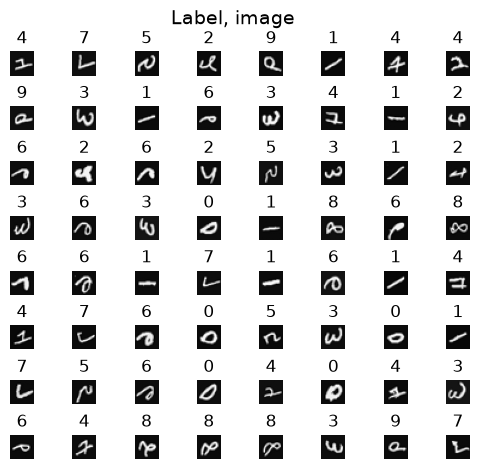

In [4]:
fig,axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91])

for i,ax in enumerate(axes.flat):
    rand_idx = np.random.randint(m)
    X_reshaped = X[rand_idx].reshape(20,20)
    ax.imshow(X_reshaped, cmap='grey')
    ax.set_title(y[rand_idx,0])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)



In [37]:


def nn_model(X_train, y_train, X_cv, y_cv, l_rate, regularizer, epoch):

    model = Sequential([
        Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(regularizer)),
        Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(regularizer)),
        Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(regularizer))
    ])

    # model.summary()
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer = tf.keras.optimizers.Adam(l_rate),
        metrics=['accuracy']
    )

    model.fit(X_train,y_train, epochs=epoch)
    print('\n')

    train_loss, train_acc = model.evaluate(X_train, y_train)
    cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
    print(f"Train Accuracy: {train_acc*100:.2f}")
    print(f"CV Accuracy: {cv_acc*100:.2f}")


In [39]:

regularizer = [0.01, 0.001,0.0001,0.0005]


model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.01)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.01))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7820 - loss: 1.5086
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8397 - loss: 1.0961
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8472 - loss: 1.0573
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8508 - loss: 1.0380
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8568 - loss: 1.0133
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8568 - loss: 0.9995
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8608 - loss: 0.9823
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8625 - loss: 0.9727
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8640 - loss: 0.9657
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8660 - loss: 0.9612
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8670 - loss: 0.9547
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

In [28]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.002),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8048 - loss: 0.9278
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.4860
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9410 - loss: 0.4078
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9560 - loss: 0.3643
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9638 - loss: 0.3370
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9697 - loss: 0.3140
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.2950
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9810 - loss: 0.2793
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9835 - loss: 0.2661
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9858 - loss: 0.2549
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9877 - loss: 0.2446
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [29]:


model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.0001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.0001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.0001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8290 - loss: 0.5957
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9262 - loss: 0.3038
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9503 - loss: 0.2352
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9538 - loss: 0.2378
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9572 - loss: 0.2263
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9630 - loss: 0.2181
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9688 - loss: 0.2042
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9762 - loss: 0.1932
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.2405
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9695 - loss: 0.2166
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9630 - loss: 0.2448
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [30]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.0005)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.0005)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.0005))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")



Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7580 - loss: 1.0466
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9115 - loss: 0.4534
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9350 - loss: 0.3687
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9480 - loss: 0.3217
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9585 - loss: 0.2898
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9670 - loss: 0.2640
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9725 - loss: 0.2431
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9760 - loss: 0.2270
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9808 - loss: 0.2139
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9843 - loss: 0.2034
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9872 - loss: 0.1947
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

### Below I have provided and retrained the finalized model
*  Train Accuracy: 98.25%

*  CV Accuracy: 92.60%

*  The Gap: Just 5.65%

In [5]:
model = Sequential([
    Dense(128, activation='relu', name='layer1',kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', name='layer2',kernel_regularizer=l2(0.001)),
    Dense(10, activation='linear', name='layer3',kernel_regularizer=l2(0.001))
])

    # model.summary()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.002),
    metrics=['accuracy']
)

model.fit(X_train,y_train, epochs=15)
print('\n')

train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")


Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 991us/step - accuracy: 0.7980 - loss: 0.9440
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9153 - loss: 0.4936  
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.9312 - loss: 0.4190
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.9457 - loss: 0.3738
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.9597 - loss: 0.3415
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.9678 - loss: 0.3157
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.9735 - loss: 0.2976
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.9775 - loss: 0.2827
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.9808 - loss: 0.2703
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.9833 - loss: 0.2607
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.9843 - loss: 0.2522
Epoch 12/15
125/125 ━━━━━━━━━━

In [22]:
X_test = np.load('./dataset/testdata/captured_2/dataset_2.npy')
y_test = np.load('./dataset/testdata/captured_2/labels_2.npy')

# X_test = X_test[:, :2]
m = X_test.shape[0]

print(X_test.shape)
print(y_test.shape)


print(X_test)

(104, 28, 28)
(104,)
[[[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 ...

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0 

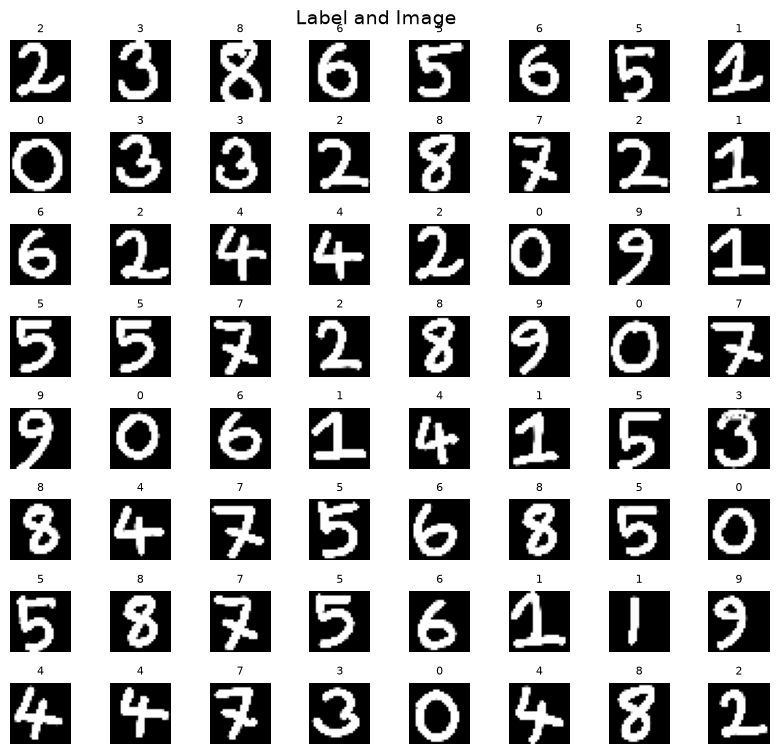

In [23]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.95])

for ax in axes.flat:
    rand_idx = np.random.randint(len(X_test))

    ax.imshow(X_test[rand_idx], cmap='gray')
    ax.set_title(str(y_test[rand_idx]), fontsize=8)
    ax.axis('off')

fig.suptitle("Label and Image", fontsize=14)
plt.show()

In [25]:
from skimage.transform import resize

# X_test has shape (104, 64, 64)

X_test_resized = np.array([
    resize(img, (20, 20), anti_aliasing=True, preserve_range=True)
    for img in X_test
])


X_test_resized = X_test_resized.astype(np.float64)

if X_test_resized.max() > 1:
    X_test_resized /= 255.0

print(X_test_resized.shape)

(104, 20, 20)


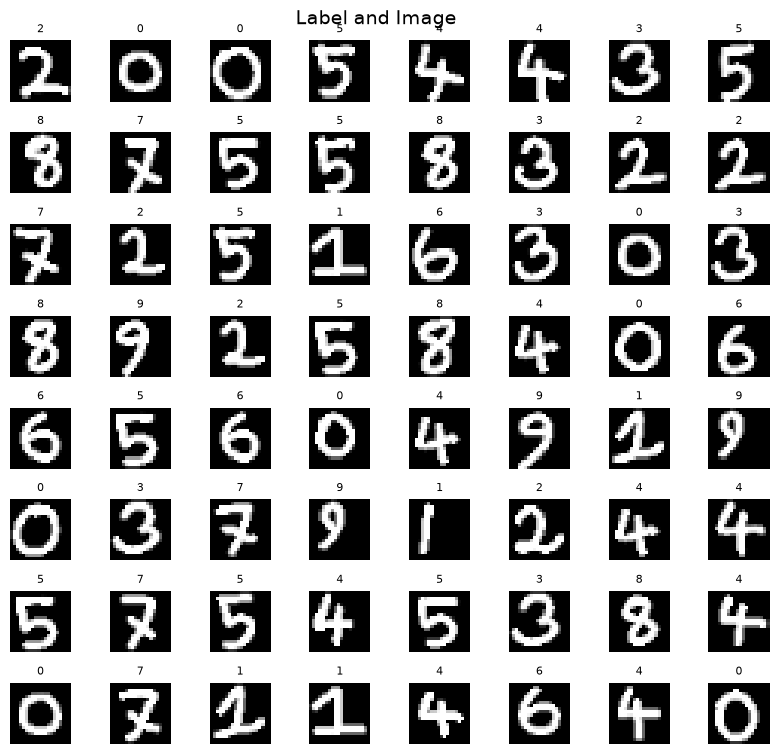

In [26]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.95])

for ax in axes.flat:
    rand_idx = np.random.randint(len(X_test))

    ax.imshow(X_test_resized[rand_idx], cmap='gray')
    ax.set_title(str(y_test[rand_idx]), fontsize=8)
    ax.axis('off')

fig.suptitle("Label and Image", fontsize=14)
plt.show()

In [28]:
X_test_resized = X_test_resized.reshape(-1, 400)
logits = model.predict(X_test_resized)
predictions = np.argmax(logits, axis=1)

print(predictions)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[6 2 0 2 6 2 0 0 2 4 7 7 4 4 4 4 5 4 4 4 4 4 4 4 4 4 2 4 6 6 6 6 2 6 6 6 2
 6 6 3 3 2 3 3 3 3 3 3 3 3 2 3 3 3 3 5 2 3 4 4 3 5 8 3 3 3 5 5 8 8 3 8 8 2
 0 2 3 2 2 2 2 2 3 9 8 6 5 6 2 2 5 5 4 4 4 6 7 5 4 4 4 4 4 4]


In [30]:
train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
test_loss, test_acc = model.evaluate(X_test_resized, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")
print(f"Test Accuracy: {test_acc*100:.2f}")



125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.9843 - loss: 0.2345
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9290 - loss: 0.4123 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0769 - loss: 8.8026 
Train Accuracy: 98.43
CV Accuracy: 92.90
Test Accuracy: 7.69


In [31]:
print(X_train.min(), X_train.max())
print(X_test_resized.min(), X_test_resized.max())

logits = model.predict(X_test_resized)
pred = np.argmax(logits, axis=1)

print(np.unique(pred, return_counts=True))
print(pred[:20])
print(y_test[:20])

-0.11993388483543918 1.127688299158888
0.0 1.0
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
(array([0, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 4, 19, 22, 26,  9, 14,  3,  6,  1]))
[6 2 0 2 6 2 0 0 2 4 7 7 4 4 4 4 5 4 4 4]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 2 2 2]


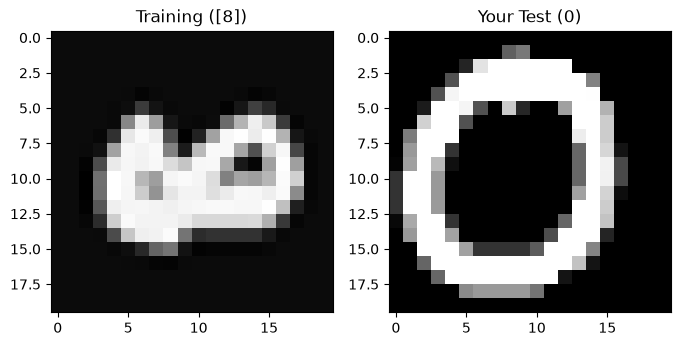

In [64]:
plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(X_train[0].reshape(20,20), cmap='gray')
plt.title(f"Training ({y_train[0]})")

plt.subplot(122)
plt.imshow(X_test_resized[0].reshape(20,20), cmap='gray')
plt.title(f"Your Test ({y_test[0]})")

plt.show()

In [60]:
import cv2
import numpy as np

def preprocess(img):
    # img should be grayscale

    # Threshold
    _, thresh = cv2.threshold(img,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Find digit bounding box
    ys, xs = np.where(thresh > 0)

    if len(xs) == 0:
        return np.zeros((20,20), dtype=np.float32)

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    digit = thresh[y1:y2+1, x1:x2+1]

    # Resize only the digit
    digit = cv2.resize(digit, (16,16), interpolation=cv2.INTER_AREA)

    # Place in center of 20x20 image
    canvas = np.zeros((20,20), dtype=np.uint8)
    canvas[2:18,2:18] = digit

    return canvas.astype(np.float32)/255.0

In [61]:
X_test_processed = np.array([preprocess(img) for img in X_test])
X_test_processed = X_test_processed.reshape(-1,400)



In [65]:
from skimage.transform import resize
from scipy import ndimage

def preprocess_like_training(images, out_size=20, digit_box=14, threshold=0.35):
    """Crop to bounding box, rescale to fit inside `digit_box`, center by
    center of mass, and pad back out to (out_size, out_size). This mimics
    the padding/margin/centering already present in the training glyphs."""
    processed = []
    for img in images:
        img = img.astype(np.float64)
        if img.max() > 0:
            img = img / img.max()

        mask = img > threshold
        if mask.sum() == 0:
            processed.append(np.zeros((out_size, out_size), dtype=np.float32))
            continue

        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]

        cropped = img[rmin:rmax + 1, cmin:cmax + 1]

        h, w = cropped.shape
        scale = digit_box / max(h, w)
        new_h = max(1, int(round(h * scale)))
        new_w = max(1, int(round(w * scale)))
        resized_digit = resize(cropped, (new_h, new_w), preserve_range=True, anti_aliasing=True)

        canvas = np.zeros((out_size, out_size))
        top = (out_size - new_h) // 2
        left = (out_size - new_w) // 2
        canvas[top:top + new_h, left:left + new_w] = resized_digit

        cy, cx = ndimage.center_of_mass(canvas)
        if not (np.isnan(cy) or np.isnan(cx)):
            shift_y, shift_x = out_size / 2 - cy, out_size / 2 - cx
            canvas = ndimage.shift(canvas, shift=(shift_y, shift_x), mode='constant', cval=0)

        processed.append(canvas.astype(np.float32))

    return np.array(processed)

X_test_aligned = preprocess_like_training(X_test)
X_test_aligned_flat = X_test_aligned.reshape(-1, 400)

print("train range:", X_train.min(), X_train.max())
print("aligned test range:", X_test_aligned_flat.min(), X_test_aligned_flat.max())

train range: -0.11993388483543918 1.127688299158888
aligned test range: -0.21208759 1.3055383


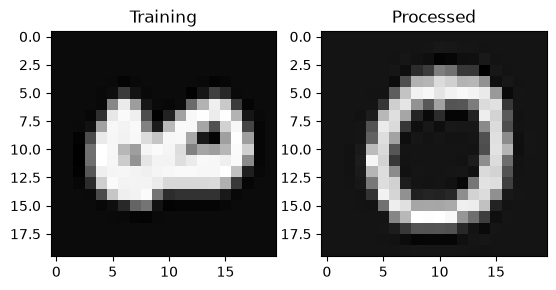

In [66]:
plt.subplot(121)
plt.imshow(X_train[0].reshape(20,20), cmap='gray')
plt.title("Training")

plt.subplot(122)
plt.imshow(X_test_aligned_flat[0].reshape(20,20), cmap='gray')
plt.title("Processed")

plt.show()

In [68]:
train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
test_loss, test_acc = model.evaluate(X_test_aligned_flat, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")
print(f"Test Accuracy: {test_acc*100:.2f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.9843 - loss: 0.2345
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9290 - loss: 0.4123 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1731 - loss: 8.5951 
Train Accuracy: 98.43
CV Accuracy: 92.90
Test Accuracy: 17.31


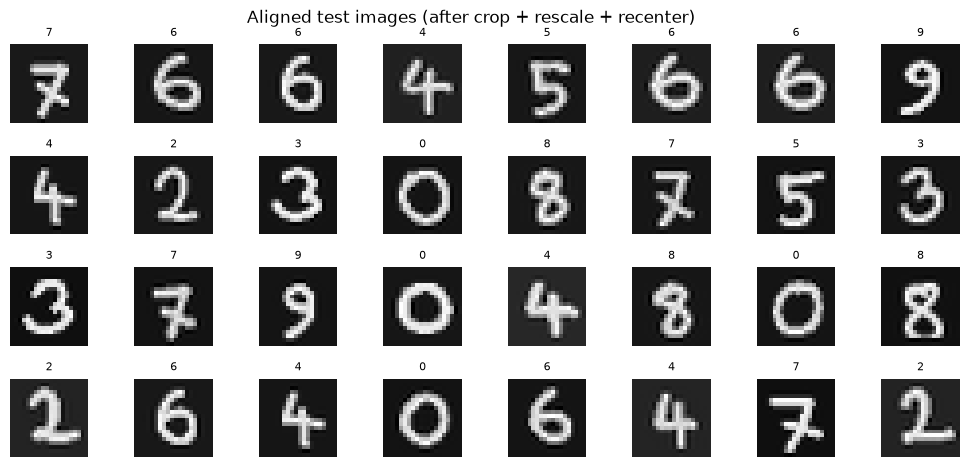

In [69]:
fig, axes = plt.subplots(4, 8, figsize=(10, 5))
fig.tight_layout(pad=0.3, rect=[0, 0.03, 1, 0.93])

for ax in axes.flat:
    rand_idx = np.random.randint(len(X_test_aligned))
    ax.imshow(X_test_aligned[rand_idx], cmap='gray')
    ax.set_title(str(y_test[rand_idx]), fontsize=8)
    ax.axis('off')

fig.suptitle("Aligned test images (after crop + rescale + recenter)", fontsize=12)
plt.show()

In [70]:
train_loss, train_acc = model.evaluate(X_train, y_train)
cv_loss, cv_acc = model.evaluate(X_cv, y_cv)
test_loss, test_acc = model.evaluate(X_test_aligned_flat, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}")
print(f"CV Accuracy: {cv_acc*100:.2f}")
print(f"Test Accuracy (aligned): {test_acc*100:.2f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.9843 - loss: 0.2345
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9290 - loss: 0.4123 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1731 - loss: 8.5951 
Train Accuracy: 98.43
CV Accuracy: 92.90
Test Accuracy (aligned): 17.31
